# EfficientNetB3 Notebook 1 — WeightedRandomSampler + Weighted Loss

## Model
EfficientNetB3

## Fixed preprocessing used in this notebook
- Black-Hat hair removal with threshold = 15
- Resize to 300×300
- ImageNet normalization
- Horizontal flip
- Vertical flip
- Small rotation
- Color jitter
- RandomErasing after `ToTensor`

## Data balancing technique
**WeightedRandomSampler + Class-Weighted CrossEntropyLoss**

The original training set is kept unchanged, but each batch is sampled with class-aware weights. The loss also gives higher weight to minority classes.

## Vast.ai setup
This notebook is designed for Vast.ai:
- Uses `/workspace/ham10000`
- Downloads dataset directly from Kaggle using username + API token
- Uses `sys.executable`
- Adds multiprocessing `fork` fix before DataLoaders


In [3]:

# ============================================================
# Cell 1 — Vast.ai Environment Setup
# ============================================================

import sys
import subprocess
import os
import json
from pathlib import Path

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

required_packages = [
    "kaggle",
    "timm",
    "opencv-python-headless",
    "scikit-learn",
    "pandas",
    "matplotlib",
    "seaborn",
    "tqdm",
    "imbalanced-learn"
]

for pkg in required_packages:
    try:
        __import__(pkg.replace("-", "_"))
    except Exception:
        install(pkg)

import torch
import torch.multiprocessing as mp

try:
    mp.set_start_method("fork", force=True)
except RuntimeError:
    pass

print("Python executable:", sys.executable)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python executable: /venv/main/bin/python
Torch version: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA H200


In [4]:

# ============================================================
# Cell 2 — Kaggle Credentials + Dataset Download for Vast.ai
# ============================================================
# Paste your Kaggle username and API token below.
# Get them from Kaggle → Account → Create New API Token.

import os
import sys
import json
import subprocess
from pathlib import Path

# --------- PASTE YOUR KAGGLE DETAILS HERE ---------
KAGGLE_USERNAME = "PASTE_YOUR_KAGGLE_USERNAME_HERE"
KAGGLE_KEY = "PASTE_YOUR_KAGGLE_API_TOKEN_HERE"
# --------------------------------------------------

DATA_ROOT = Path("/workspace/ham10000")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

# Make sure kaggle package exists inside THIS Python environment
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "kaggle"
])

kaggle_dir = Path("/root/.kaggle")
kaggle_dir.mkdir(parents=True, exist_ok=True)

kaggle_json_path = kaggle_dir / "kaggle.json"

with open(kaggle_json_path, "w") as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)

os.chmod(kaggle_json_path, 0o600)

print("Kaggle credentials saved to:", kaggle_json_path)

zip_path = DATA_ROOT / "skin-cancer-mnist-ham10000.zip"
metadata_path = DATA_ROOT / "HAM10000_metadata.csv"

if not metadata_path.exists():
    print("Downloading HAM10000 from Kaggle using python -m kaggle...")

    subprocess.check_call([
        sys.executable, "-m", "kaggle",
        "datasets", "download",
        "-d", "kmader/skin-cancer-mnist-ham10000",
        "-p", str(DATA_ROOT)
    ])

    if not zip_path.exists():
        raise FileNotFoundError(f"Download failed. Zip file not found at: {zip_path}")

    print("Extracting dataset...")
    subprocess.check_call([
        "unzip", "-q", str(zip_path), "-d", str(DATA_ROOT)
    ])

    if zip_path.exists():
        print("Removing zip to save disk space...")
        zip_path.unlink()

else:
    print("Dataset already exists. Skipping download.")

print("\nFiles in DATA_ROOT:")
for p in sorted(DATA_ROOT.iterdir()):
    print("-", p.name)


Kaggle credentials saved to: /root/.kaggle/kaggle.json
Dataset already exists. Skipping download.

Files in DATA_ROOT:
- HAM10000_images_part_1
- HAM10000_images_part_2
- HAM10000_metadata.csv
- ham10000_images_part_1
- ham10000_images_part_2
- skin-cancer-mnist-ham10000.zip


In [5]:

# ============================================================
# Cell 3 — Imports and Configuration
# ============================================================

import random
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils import resample

from imblearn.over_sampling import SMOTE

import timm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_NAME = "efficientnet_b3"
IMG_SIZE = 300
BATCH_SIZE = 32
EPOCHS = 25
PATIENCE = 7
NUM_WORKERS = 2

CSV_PATH = DATA_ROOT / "HAM10000_metadata.csv"

IMAGE_DIRS = [
    DATA_ROOT / "HAM10000_images_part_1",
    DATA_ROOT / "HAM10000_images_part_2"
]

HAIR_REMOVED_DIR = DATA_ROOT / "hair_removed_threshold15"

print("Device:", DEVICE)
print("Data root:", DATA_ROOT)


Device: cuda
Data root: /workspace/ham10000


In [6]:

# ============================================================
# Cell 4 — Load Metadata and Build Image Paths
# ============================================================

df = pd.read_csv(CSV_PATH)

image_path_map = {}

for image_dir in IMAGE_DIRS:
    for img_path in image_dir.glob("*.jpg"):
        image_path_map[img_path.stem] = img_path

df["image_path"] = df["image_id"].map(image_path_map)

missing = df["image_path"].isna().sum()
print("Missing image paths:", missing)

df = df.dropna(subset=["image_path"]).reset_index(drop=True)

classes = sorted(df["dx"].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

df["label"] = df["dx"].map(class_to_idx)

print("Classes:", classes)
print(df["dx"].value_counts())


Missing image paths: 0
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [7]:

# ============================================================
# Cell 5 — Black-Hat Hair Removal Function
# ============================================================

def remove_hair_blackhat(image_bgr, threshold=15):
    """
    Black-Hat hair removal for dermoscopic images.
    Threshold is set to 15 to avoid overly aggressive removal.
    """
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, threshold, 255, cv2.THRESH_BINARY)
    cleaned = cv2.inpaint(image_bgr, mask, 1, cv2.INPAINT_TELEA)
    return cleaned


In [8]:

# ============================================================
# Cell 6 — Create Offline Hair-Removed Images
# ============================================================

HAIR_REMOVED_DIR.mkdir(parents=True, exist_ok=True)

for _, row in tqdm(df.iterrows(), total=len(df)):
    src_path = Path(row["image_path"])
    dst_path = HAIR_REMOVED_DIR / src_path.name

    if dst_path.exists():
        continue

    img = cv2.imread(str(src_path))
    if img is None:
        continue

    cleaned = remove_hair_blackhat(img, threshold=15)
    cv2.imwrite(str(dst_path), cleaned)

df["processed_path"] = df["image_id"].apply(lambda x: HAIR_REMOVED_DIR / f"{x}.jpg")

print("Hair-removed directory:", HAIR_REMOVED_DIR)
print("Processed files:", len(list(HAIR_REMOVED_DIR.glob('*.jpg'))))


  0%|          | 0/10015 [00:00<?, ?it/s]

Hair-removed directory: /workspace/ham10000/hair_removed_threshold15
Processed files: 10015


In [9]:

# ============================================================
# Cell 7 — Split Data FIRST to Prevent Leakage
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df), train_df["dx"].value_counts().to_dict())
print("Val:", len(val_df), val_df["dx"].value_counts().to_dict())
print("Test:", len(test_df), test_df["dx"].value_counts().to_dict())


Train: 7010 {'nv': 4693, 'mel': 779, 'bkl': 769, 'bcc': 360, 'akiec': 229, 'vasc': 99, 'df': 81}
Val: 1502 {'nv': 1006, 'mel': 167, 'bkl': 165, 'bcc': 77, 'akiec': 49, 'vasc': 21, 'df': 17}
Test: 1503 {'nv': 1006, 'mel': 167, 'bkl': 165, 'bcc': 77, 'akiec': 49, 'vasc': 22, 'df': 17}


In [10]:

# ============================================================
# Cell 8 — Balancing Technique 1: WeightedRandomSampler + Class-Weighted Loss
# ============================================================

BALANCING_TAG = "weighted_sampler_weighted_loss"
USE_WEIGHTED_SAMPLER = True

train_df_balanced = train_df.copy().reset_index(drop=True)

class_counts = train_df_balanced["label"].value_counts().sort_index().values
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)

sample_weights = train_df_balanced["label"].map(lambda x: class_weights[x]).values

train_sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

LOSS_FUNCTION = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
)

print("Balancing:", BALANCING_TAG)
print("Class counts:", class_counts)
print("Class weights:", class_weights)


Balancing: weighted_sampler_weighted_loss
Class counts: [ 229  360  769   81  779 4693   99]
Class weights: [0.94378354 0.6003512  0.28104867 2.66822754 0.27744086 0.04605294
 2.18309526]


/tmp/ipykernel_2690/3585204616.py:17: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  weights=torch.DoubleTensor(sample_weights),


In [11]:

# ============================================================
# Cell 9 — Transforms
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.10),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.20, scale=(0.02, 0.12), ratio=(0.3, 3.3)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [12]:

# ============================================================
# Cell 10 — Dataset Class
# ============================================================

class HAMDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = Path(row["processed_path"])

        image = Image.open(img_path).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label


In [13]:

# ============================================================
# Cell 11 — DataLoaders
# ============================================================

train_dataset = HAMDataset(train_df_balanced, transform=train_transform)
val_dataset = HAMDataset(val_df, transform=eval_transform)
test_dataset = HAMDataset(test_df, transform=eval_transform)

if USE_WEIGHTED_SAMPLER:
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=train_sampler,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )
else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))
print("Train batches:", len(train_loader))


Train samples: 7010
Val samples: 1502
Test samples: 1503
Train batches: 220


In [14]:

# ============================================================
# Cell 12 — Model, Loss, Optimizer
# ============================================================

model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=len(classes)
).to(DEVICE)

criterion = LOSS_FUNCTION

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

print("Model:", MODEL_NAME)
print("Balancing:", BALANCING_TAG)


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Model: efficientnet_b3
Balancing: weighted_sampler_weighted_loss


In [15]:

# ============================================================
# Cell 13 — Training and Evaluation Functions
# ============================================================

def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in tqdm(loader, leave=False):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    all_probs = []

    for images, labels in tqdm(loader, leave=False):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)

        running_loss += loss.item() * images.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1, np.array(all_labels), np.array(all_preds), np.array(all_probs)


In [16]:

# ============================================================
# Cell 14 — Train with Early Stopping
# ============================================================

history = []
best_val_f1 = -1
best_path = f"{MODEL_NAME}_{BALANCING_TAG}_best.pt"
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader)
    val_loss, val_acc, val_f1, _, _, _ = evaluate(model, val_loader)

    scheduler.step()

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_macro_f1": train_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_macro_f1": val_f1
    })

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Macro F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   Macro F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), best_path)
        print("Saved best model:", best_path)
    else:
        patience_counter += 1
        print("Patience:", patience_counter, "/", PATIENCE)

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(f"{MODEL_NAME}_{BALANCING_TAG}_history.csv", index=False)
history_df



Epoch 1/25


  0%|          | 0/220 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 0.7845 | Train Acc: 0.4949 | Train Macro F1: 0.4511
Val   Loss: 1.2794 | Val   Acc: 0.3835 | Val   Macro F1: 0.3478
Saved best model: efficientnet_b3_weighted_sampler_weighted_loss_best.pt

Epoch 2/25


  0%|          | 0/220 [00:00<?, ?it/s]

...

Train Loss: 0.0220 | Train Acc: 0.9498 | Train Macro F1: 0.9479
Val   Loss: 0.7191 | Val   Acc: 0.7716 | Val   Macro F1: 0.7082
Patience: 2 / 7

Epoch 25/25


  0%|          | 0/220 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 0.0219 | Train Acc: 0.9462 | Train Macro F1: 0.9439
Val   Loss: 0.6752 | Val   Acc: 0.7670 | Val   Macro F1: 0.6954
Patience: 3 / 7


,epoch,train_loss,train_acc,train_macro_f1,val_loss,val_acc,val_macro_f1
0,1,0.784517,0.494864,0.451118,1.279441,0.383489,0.347809
1,2,0.279546,0.724679,0.710252,1.031469,0.561917,0.482658
2,3,0.178613,0.786733,0.778978,0.916344,0.627830,0.568795
3,4,0.131423,0.827389,0.820747,0.877071,0.613182,0.519458
4,5,0.101442,0.859914,0.853857,0.818816,0.661784,0.595540
5,6,0.075524,0.874893,0.868987,0.807315,0.682423,0.655771
6,7,0.084173,0.877889,0.871499,0.823788,0.687750,0.627004
7,8,0.075292,0.893581,0.891770,0.787578,0.689081,0.664212
8,9,0.050748,0.907418,0.902201,0.740360,0.715712,0.643925
9,10,0.050914,0.904422,0.897007,0.698511,0.688415,0.627170


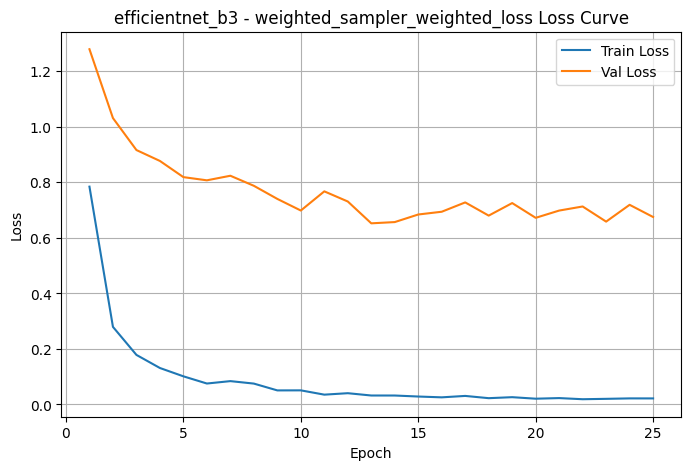

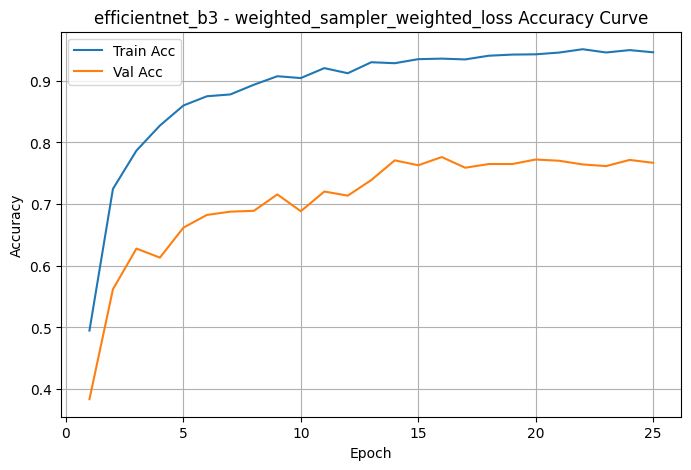

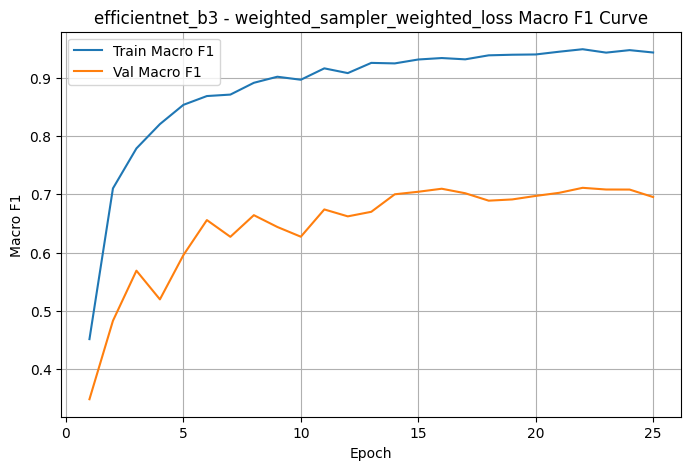

In [17]:

# ============================================================
# Cell 15 — Learning Curves
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{MODEL_NAME} - {BALANCING_TAG} Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Acc")
plt.plot(history_df["epoch"], history_df["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_NAME} - {BALANCING_TAG} Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_macro_f1"], label="Train Macro F1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="Val Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title(f"{MODEL_NAME} - {BALANCING_TAG} Macro F1 Curve")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:

# ============================================================
# Cell 16 — Final Test Evaluation
# ============================================================

model.load_state_dict(torch.load(best_path, map_location=DEVICE))

test_loss, test_acc, test_f1, y_true, y_pred, y_probs = evaluate(model, test_loader)

y_true_bin = label_binarize(y_true, classes=list(range(len(classes))))

try:
    auc_macro = roc_auc_score(y_true_bin, y_probs, average="macro", multi_class="ovr")
    auc_micro = roc_auc_score(y_true_bin, y_probs, average="micro", multi_class="ovr")
except Exception as e:
    auc_macro = None
    auc_micro = None
    print("ROC AUC calculation failed:", e)

print("FINAL TEST METRICS")
print("Model:", MODEL_NAME)
print("Balancing:", BALANCING_TAG)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro F1: {test_f1:.4f}")
print("ROC AUC Macro:", auc_macro)
print("ROC AUC Micro:", auc_micro)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes))


In [ ]:

# ============================================================
# Cell 17 — Confusion Matrix
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"{MODEL_NAME} - {BALANCING_TAG} Confusion Matrix")
plt.show()


In [ ]:

# ============================================================
# Cell 18 — Save Final Summary
# ============================================================

summary = {
    "model": MODEL_NAME,
    "balancing": BALANCING_TAG,
    "preprocessing": "Black-Hat hair removal threshold=15, resize 300x300, ImageNet norm, flips, rotation, color jitter, RandomErasing",
    "test_loss": test_loss,
    "test_accuracy": test_acc,
    "test_macro_f1": test_f1,
    "roc_auc_macro": auc_macro,
    "roc_auc_micro": auc_micro,
    "best_val_macro_f1": best_val_f1,
    "best_model_path": best_path
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(f"{MODEL_NAME}_{BALANCING_TAG}_summary.csv", index=False)
summary_df
